# Diseño de Sistema de Generación Fotovoltaica On-Grid

---

| | |
|---|---|
| **Cliente** | MEHCCO SA |
| **Suministro** | Tarifa T2 — EDENOR |
| **Ubicación** | Ricardo Güiraldes 4567, B1650MDE Villa Juan, Buenos Aires, Argentina |
| **Período de referencia** | 16/03/2026 al 15/04/2026 |
| **Fecha del informe** | 2026 |

---
Ricardo Güiraldes 4567,


## 0. Entorno — Instalación de dependencias

Ejecutar esta celda la primera vez para instalar las bibliotecas necesarias.

In [ ]:
import subprocess, sys

def instalar(paquete):
    subprocess.check_call([sys.executable, "-m", "pip", "install", paquete, "-q"])

for pkg in ["pvlib", "pandas", "numpy", "matplotlib", "requests", "tabulate"]:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Instalando {pkg}...")
        instalar(pkg)

print("✓ Todas las dependencias disponibles")


✓ Todas las dependencias disponibles


## 0.1. Importaciones y configuración general

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings('ignore')

import pvlib
from pvlib import location, irradiance, temperature
from pvlib.pvsystem import pvwatts_dc
from pvlib.inverter import pvwatts as pvwatts_ac

# ── Estilo de gráficos ──────────────────────────────────────
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.dpi'     : 120,
    'figure.figsize' : (11, 4),
    'axes.grid'      : True,
    'grid.alpha'     : 0.15,
    'font.family'    : 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

import matplotlib.pyplot as plt

# Configuraciones globales para forzar fondo claro y textos oscuros
%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': 'white',       # Fondo exterior de la imagen blanco
    'axes.facecolor': 'white',         # Fondo del gráfico blanco
    'savefig.facecolor': 'white',      # Fuerza fondo blanco al guardar el archivo PNG
    'text.color': '#1f2937',           # Color de texto oscuro para que se lea bien
    'axes.labelcolor': '#1f2937',      # Color de etiquetas de los ejes oscuro
    'xtick.color': '#1f2937',          # Color de números en el eje X
    'ytick.color': '#1f2937'           # Color de números en el eje Y
})

print(f"pvlib  : {pvlib.__version__}")
print(f"pandas : {pd.__version__}")
print("✓ Entorno listo")


pvlib  : 0.15.1
pandas : 2.3.3
✓ Entorno listo


---
## 1. Datos del proyecto
### ⚙️ PARÁMETROS EDITABLES — Modificar acá para recalcular todo el informe


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         PARÁMETROS EDITABLES DEL PROYECTO                   ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Datos del sitio ─────────────────────────────────────────
LATITUD      = -34.5747566     # grados decimales (Sur = negativo)
LONGITUD     = -58.5564361     # grados decimales (Oeste = negativo)
ALTITUD      = 20           # metros sobre el nivel del mar
ZONA_HORARIA = 'America/Buenos_Aires'
NOMBRE_SITIO = 'MEHCCO SA — Gral. San Martín, PBA'

# ── Datos del suministro ─────────────────────────────────────
P_CONTRATADA_KW   = 16.0    # kW — potencia contratada con EDENOR
TARIFA            = 'T2'
DISTRIBUIDOR      = 'EDENOR'

# ── Consumo histórico (completar con facturas disponibles) ───
CONSUMO_HISTORICO = {
    'periodo'    : ['Ene-26', 'Feb-26', 'Mar-26', 'Abr-26'],
    'energia_kwh': [4864,      5291,     4646,     4173    ],
    'potencia_kw': [44.00,     49.00,    35.00,    34.68   ],
}

# ── Factura de referencia (período Abr-2026) ─────────────────
FACTURA = {
    'energia_kwh'     : 4173,
    'potencia_max_kw' : 34.68,
    'cargo_fijo'      : 40_691,
    'pot_contratada'  : 305_102,
    'pot_adquirida'   : 299_218,
    'pot_excedida'    : 534_311,
    'energia_activa'  : 343_705,
    'impuestos'       : 569_993,
    'tasa_municipal'  : 8_700,
    'total_factura'   : 2_101_720,
}

# ── Datos del techo ──────────────────────────────────────────
AREA_TECHO_M2       = 140     # m² — área disponible (VERIFICAR)
INCLINACION_GRADOS  =  34    # ángulo de inclinación del panel (o angulo del techo si va directo)
ACIMUT_GRADOS       = -46      # grados desde Norte (0=N, 90=E, -90=O)

# ── Perfil laboral ───────────────────────────────────────────
HORA_INICIO_TURNO = 8         # hora de inicio de actividad
HORA_FIN_TURNO    = 18        # hora de fin de actividad
DIAS_LABORALES    = [0,1,2,3,4,5]  # 0=Lun ... 5=Sáb (domingo excluido)
SABADO_MEDIO_DIA  = True      # True = sábado solo hasta las 13hs

# ── Parámetros del panel FV (datasheet) ─────────────────────
PANEL = {
    'modelo'        : 'Vertex TSM-NEG19RC.20 625W',
    'Wp'            : 625,      # W — potencia pico STC habría que sumarle
    'Voc_stc'       : 49.9,    # V
    'Vmpp_stc'      : 41.7,    # V
    'Isc_stc'       : 15.92,    # A
    'Impp_stc'      : 15,    # A
    'beta_oc'       : -0.240,   # %/°C — coef. temp. de Voc
    'alpha_isc'     : 0.040,    # %/°C — coef. temp. de Isc
    'gamma_pmpp'    : -0.290,   # %/°C — coef. temp. de Pmpp
    'NOCT'          : 43,       # °C - temperatura nominal de trabajo
    'largo_mm'      : 2382,     # mm
    'ancho_mm'      : 1234,     # mm
    'V_sys_max'     : 1500,     # V — tensión máxima del sistema
    'ganancia_bifacial': 0.1  # en caso que sea bifacial, 0 si no es
}

# ── Parámetros del inversor (datasheet) ─────────────────────
INVERSOR = {
    'modelo'        : 'Fronius Symo 15.0-3-M',
    'P_ac_nom_w'    : 15000,    # W — potencia nominal AC
    'P_dc_max_w'    : 22500,    # W — potencia DC máxima admisible
    'V_dc_max'      : 1000,     # V — tensión DC máxima absoluta
    'V_mppt_min'    : 200,      # V — límite inferior del rango MPPT
    'V_mppt_max'    : 800,      # V — límite superior del rango MPPT
    'I_dc_max'      : 27.0,     # A — corriente DC máxima por MPPT
    'I_sc_max'      : 33.0,     # A — corriente de cortocircuito DC máx
    'n_mppt'        : 2,        # cantidad de entradas MPPT
    'eta_max'       : 0.975,    # eficiencia máxima
    'eta_euro'      : 0.971,    # eficiencia europea (ponderada)
    'fases'         : 3,        # 1 = monofásico, 3 = trifásico
    'V_ac'          : 380,      # V — tensión de red AC
}

# ── Condiciones extremas de temperatura ─────────────────────
T_CEL_MIN  = -5.0    # °C — temperatura mínima de celda (peor caso BsAs)
T_CEL_MAX  = 71.0    # °C — temperatura máxima de celda (peor caso BsAs)
T_AMB_MIN  = -2.0    # °C — temperatura ambiente mínima del sitio
T_AMB_MAX  = 40.0    # °C — temperatura ambiente máxima del sitio

# ── Performance Ratio ────────────────────────────────────────
PR = 0.78            # Performance Ratio global del sistema, lo pusimos a ojo
parametros_md = f"""

---

### 📋 Resumen de Parámetros del Proyecto

---

| 🌍 Ubicación y Suministro | Detalle |
| :--- | :--- |
| **Sitio** | {NOMBRE_SITIO} |
| **Coordenadas** | {LATITUD}, {LONGITUD} (Altitud: {ALTITUD}m) |
| **Distribuidor / Tarifa** | {DISTRIBUIDOR} — Tarifa {TARIFA} |
| **Potencia Contratada** | {P_CONTRATADA_KW} kW |

<br>

| ⚙️ Equipamiento Seleccionado | Especificaciones |
| :--- | :--- |
| **Panel Solar** | {PANEL['modelo']} — **{PANEL['Wp']} Wp** |
| **Inversor** | {INVERSOR['modelo']} — **{INVERSOR['P_ac_nom_w']/1000:.1f} kW AC** |
| **Performance Ratio (PR)** | {PR*100:.0f}% |

<br>

| 📐 Geometría del Techo | Medida |
| :--- | :--- |
| **Área Disponible** | {AREA_TECHO_M2} m² |
| **Inclinación (Tilt)** | {INCLINACION_GRADOS}° |
| **Acimut** | {ACIMUT_GRADOS}° |

---
"""

display(Markdown(parametros_md))



---

### 📋 Resumen de Parámetros del Proyecto

---

| 🌍 Ubicación y Suministro | Detalle |
| :--- | :--- |
| **Sitio** | MEHCCO SA — Gral. San Martín, PBA |
| **Coordenadas** | -34.5747566, -58.5564361 (Altitud: 20m) |
| **Distribuidor / Tarifa** | EDENOR — Tarifa T2 |
| **Potencia Contratada** | 16.0 kW |

<br>

| ⚙️ Equipamiento Seleccionado | Especificaciones |
| :--- | :--- |
| **Panel Solar** | Vertex TSM-NEG19RC.20 625W — **625 Wp** |
| **Inversor** | Fronius Symo 15.0-3-M — **15.0 kW AC** |
| **Performance Ratio (PR)** | 78% |

<br>

| 📐 Geometría del Techo | Medida |
| :--- | :--- |
| **Área Disponible** | 140 m² |
| **Inclinación (Tilt)** | 34° |
| **Acimut** | -46° |

---


---
## 2. Análisis del estado actual

### 2.1 Descripción del suministro


In [ ]:
# Construir DataFrame de la factura
factura_df = pd.DataFrame({
    'Concepto': [
        'Cargo fijo',
        'Potencia Contratada',
        'Potencia Adquirida',
        'Potencia Excedida',
        'Energía Activa',
    ],
    'Importe ($)': [
        FACTURA['cargo_fijo'],
        FACTURA['pot_contratada'],
        FACTURA['pot_adquirida'],
        FACTURA['pot_excedida'],
        FACTURA['energia_activa'],
    ],
})
total_electrico = factura_df['Importe ($)'].sum()
factura_df['Participación (%)'] = (
    factura_df['Importe ($)'] / total_electrico * 100
).round(1)
factura_df['Importe ($)'] = factura_df['Importe ($)'].apply(lambda x: f"$ {x:,.0f}")

print("═" * 55)
print("  COMPOSICIÓN DE LA FACTURA — CONCEPTOS ELÉCTRICOS")
print("═" * 55)
print(factura_df.to_string(index=False))
print("─" * 55)
print(f"  Total conceptos eléctricos : $ {total_electrico:,.0f}")
print(f"  Impuestos y contribuciones : $ {FACTURA['impuestos']:,.0f}")
print(f"  Tasa municipal             : $ {FACTURA['tasa_municipal']:,.0f}")
print(f"  TOTAL FACTURA              : $ {FACTURA['total_factura']:,.0f}")
print("═" * 55)
print()
print(f"  ⚠  Potencia CONTRATADA : {P_CONTRATADA_KW:.1f} kW")
print(f"  ⚠  Potencia CONSUMIDA  : {FACTURA['potencia_max_kw']:.2f} kW")
print(f"  ⚠  Potencia EXCEDIDA   : {FACTURA['potencia_max_kw'] - P_CONTRATADA_KW:.2f} kW")
print()
print(f"  Cargo por excedida representa el "
      f"{FACTURA['pot_excedida']/total_electrico*100:.1f}% del total eléctrico")


═══════════════════════════════════════════════════════
  COMPOSICIÓN DE LA FACTURA — CONCEPTOS ELÉCTRICOS
═══════════════════════════════════════════════════════
           Concepto Importe ($)  Participación (%)
         Cargo fijo    $ 40,691                2.7
Potencia Contratada   $ 305,102               20.0
 Potencia Adquirida   $ 299,218               19.6
  Potencia Excedida   $ 534,311               35.1
     Energía Activa   $ 343,705               22.6
───────────────────────────────────────────────────────
  Total conceptos eléctricos : $ 1,523,027
  Impuestos y contribuciones : $ 569,993
  Tasa municipal             : $ 8,700
  TOTAL FACTURA              : $ 2,101,720
═══════════════════════════════════════════════════════

  ⚠  Potencia CONTRATADA : 16.0 kW
  ⚠  Potencia CONSUMIDA  : 34.68 kW
  ⚠  Potencia EXCEDIDA   : 18.68 kW

  Cargo por excedida representa el 35.1% del total eléctrico


### 2.2 Gráfico — Composición de la factura

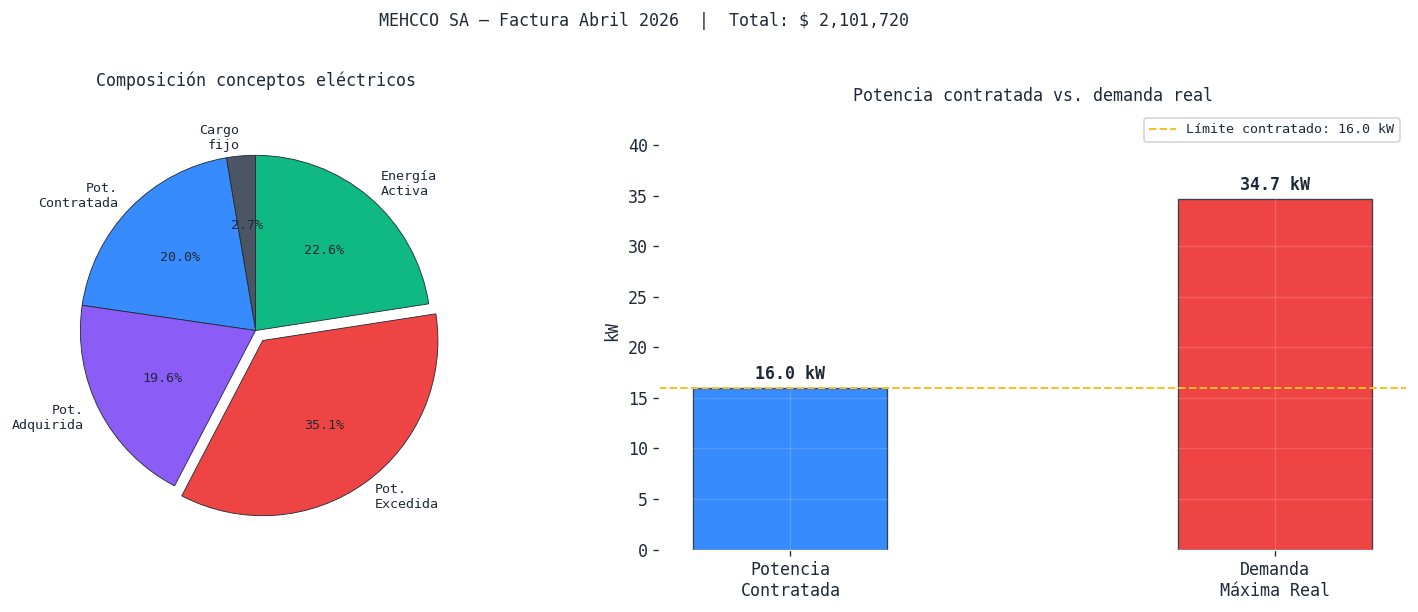

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Torta de composición ─────────────────────────────────────
conceptos = ['Cargo\nfijo', 'Pot.\nContratada', 'Pot.\nAdquirida',
             'Pot.\nExcedida', 'Energía\nActiva']
importes  = [FACTURA['cargo_fijo'], FACTURA['pot_contratada'],
             FACTURA['pot_adquirida'], FACTURA['pot_excedida'],
             FACTURA['energia_activa']]
colores   = ['#4b5563', '#388bfd', '#8b5cf6', '#ef4444', '#10b981']
explode   = [0, 0, 0, 0.07, 0]

wedges, texts, autotexts = ax1.pie(
    importes, labels=conceptos, autopct='%1.1f%%',
    colors=colores, explode=explode, startangle=90,
    textprops={'fontsize': 8},
    wedgeprops={'linewidth': 0.5, 'edgecolor': '#1f2937'}
)
for at in autotexts:
    at.set_fontsize(8)
ax1.set_title('Composición conceptos eléctricos', fontsize=10, pad=15)

# ── Barras comparativa contratada vs consumida ───────────────
categorias = ['Potencia\nContratada', 'Demanda\nMáxima Real']
valores    = [P_CONTRATADA_KW, FACTURA['potencia_max_kw']]
bar_colors = ['#388bfd', '#ef4444']
bars = ax2.bar(categorias, valores, color=bar_colors, width=0.4,
               edgecolor='#374151', linewidth=0.8)
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f} kW', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(P_CONTRATADA_KW, color='#fbbf24', linestyle='--',
            linewidth=1.2, label=f'Límite contratado: {P_CONTRATADA_KW} kW')
ax2.set_ylabel('kW')
ax2.set_title('Potencia contratada vs. demanda real', fontsize=10)
ax2.legend(fontsize=8)
ax2.set_ylim(0, FACTURA['potencia_max_kw'] * 1.25)

plt.suptitle(f'MEHCCO SA — Factura Abril 2026  |  Total: $ {FACTURA["total_factura"]:,.0f}',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('factura_composicion.png', bbox_inches='tight', dpi=120)
plt.show()


### 2.3 Consumo histórico y costo efectivo del kWh

In [ ]:
# DataFrame histórico
hist = pd.DataFrame(CONSUMO_HISTORICO)
hist['consumo_diario'] = (hist['energia_kwh'] / 30).round(1)

# Precio efectivo del kWh (todos los cargos variables / energía consumida)
p_efectivo = (FACTURA['total_factura'] - FACTURA['cargo_fijo']) / FACTURA['energia_kwh']

print(f"{'Período':<12} {'Energía (kWh)':<18} {'Diario (kWh/día)':<20} {'Potencia máx (kW)'}")
print("─" * 65)
for _, row in hist.iterrows():
    print(f"{row['periodo']:<12} {row['energia_kwh']:<18,.0f} "
          f"{row['consumo_diario']:<20.1f} {row['potencia_kw']:.2f}")
print("─" * 65)
print(f"{'Promedio':<12} {hist['energia_kwh'].mean():<18,.0f} "
      f"{hist['consumo_diario'].mean():<20.1f} {hist['potencia_kw'].mean():.2f}")

print()
print(f"  Consumo promedio mensual  : {hist['energia_kwh'].mean():,.0f} kWh/mes")
print(f"  Consumo diario promedio   : {hist['consumo_diario'].mean():.1f} kWh/día")
print(f"  Precio efectivo del kWh   : $ {p_efectivo:,.0f} /kWh")
print(f"  (incluye energía + potencia + impuestos + tasas)")

# Supuesto de perfil horario
horas_turno = HORA_FIN_TURNO - HORA_INICIO_TURNO
consumo_hora = hist['consumo_diario'].mean() / horas_turno
print()
print(f"  Perfil de carga supuesto  : {HORA_INICIO_TURNO}:00 a {HORA_FIN_TURNO}:00 hs")
print(f"  Días laborales            : Lunes a Viernes + Sábado hasta 13hs")
print(f"  Consumo medio por hora    : {consumo_hora:.1f} kWh/h (estimación uniforme)")
print(f"  Demanda media en turno    : {consumo_hora:.1f} kW (estimación)")


Período      Energía (kWh)      Diario (kWh/día)     Potencia máx (kW)
─────────────────────────────────────────────────────────────────
Ene-26       4,864              162.1                44.00
Feb-26       5,291              176.4                49.00
Mar-26       4,646              154.9                35.00
Abr-26       4,173              139.1                34.68
─────────────────────────────────────────────────────────────────
Promedio     4,744              158.1                40.67

  Consumo promedio mensual  : 4,744 kWh/mes
  Consumo diario promedio   : 158.1 kWh/día
  Precio efectivo del kWh   : $ 494 /kWh
  (incluye energía + potencia + impuestos + tasas)

  Perfil de carga supuesto  : 8:00 a 18:00 hs
  Días laborales            : Lunes a Viernes + Sábado hasta 13hs
  Consumo medio por hora    : 15.8 kWh/h (estimación uniforme)
  Demanda media en turno    : 15.8 kW (estimación)


---
## 3. Recurso solar del sitio

### 3.1 Posición geográfica y descarga de datos TMY desde PVGIS


In [ ]:
from pvlib.iotools import get_pvgis_tmy

# Definir la ubicación con pvlib
sitio = location.Location(
    latitude  = LATITUD,
    longitude = LONGITUD,
    altitude  = ALTITUD,
    tz        = ZONA_HORARIA,
    name      = NOMBRE_SITIO,
)
print(f"Sitio definido: {sitio.name}")
print(f"  Lat: {sitio.latitude}° | Lon: {sitio.longitude}° | Alt: {sitio.altitude} m")
print()
print("Descargando TMY desde PVGIS...")

try:
    # Ajustado a 2 variables de retorno (data, metadata) según la API actual de pvlib
    # Respecto de la irradiancia, devuelve la irradiancia en superficie horizontal, sin acimut
    tmy_data, metadata = get_pvgis_tmy(
        latitude      = LATITUD,
        longitude     = LONGITUD,
        usehorizon    = True,
        startyear     = 2005,
        endyear       = 2020,
        map_variables = True  # Estandariza los nombres de las columnas automáticamente
    )
    print(f"✓ TMY descargado: {len(tmy_data)} registros horarios (8760 h/año)")
    print(f"  Variables: {list(tmy_data.columns)}")

    # Si necesitás acceder a los meses seleccionados, ahora están guardados acá:
    # months_sel = metadata['outputs']['months_selected']

except Exception as e:
    print(f"⚠ No se pudo descargar el TMY online: {e}")
    print("  Usando datos manuales de PVGIS como respaldo...")
    tmy_data = None



Sitio definido: MEHCCO SA — Gral. San Martín, PBA
  Lat: -34.5747566° | Lon: -58.5564361° | Alt: 20 m

Descargando TMY desde PVGIS...
✓ TMY descargado: 8760 registros horarios (8760 h/año)
  Variables: ['temp_air', 'relative_humidity', 'ghi', 'dni', 'dhi', 'IR(h)', 'wind_speed', 'wind_direction', 'pressure']


### 3.2 Irradiancia sobre el plano del array (POA)

In [ ]:
import pandas as pd

# Genera el índice horario de 8760 registros (times) necesario para la simulación anual
# del recurso solar con pvlib.
times = pd.date_range(
    start='2023-01-01', periods=8760, freq='h', tz=ZONA_HORARIA
)

if tmy_data is not None:
    tmy_data.index = times

    # Calcula la posición solar (cenit y acimut aparente) para cada hora del año en
    # la ubicación definida.
    solar_pos = sitio.get_solarposition(times)

    #Calcula la irradiancia total sobre el plano del array (POA) a partir de la inclinación,
    # acimut, posición solar y componentes DNI/GHI/DHI del TMY.
    # GHI (Global Horizontal Irradiance - Radiación Global Horizontal)
    # DNI (Direct Normal Irradiance - Radiación Directa Normal)
    # DHI (Diffuse Horizontal Irradiance - Radiación Difusa Horizontal)

    poa = irradiance.get_total_irradiance(
        surface_tilt    = INCLINACION_GRADOS,
        surface_azimuth = ACIMUT_GRADOS,
        solar_zenith    = solar_pos['apparent_zenith'],
        solar_azimuth   = solar_pos['azimuth'],
        dni = tmy_data['dni'],
        ghi = tmy_data['ghi'],
        dhi = tmy_data['dhi'],
    )
    # Filtra y se queda únicamente con la Radiación Global en el Plano del Arreglo.
    # Esta es la suma total de toda la energía (directa + difusa + reflejo del suelo)
    # que golpea de frente a los paneles. Es el valor real que usará tu sistema para
    # generar electricidad.
    G_poa = poa['poa_global'].fillna(0)

    # HPS mensual
    # En este paso, calcula la energia en kWh por mes, el G_poa está el dato de la irradiancia
    # por hora en el año. Como es la irradiancia por año, el resultado da la irradiación en
    # wh/mes, por eso se divide por mil
    hps_mes   = G_poa.resample('ME').sum() / 1000
    # Cuenta los días del mes
    dias_mes  = G_poa.resample('ME').count() / 24
    # calcula la irradiación por día, donde el resultado justamente es el HPS, ya que
    # las horas solares pico son horas a irradianica a  1000w/m^2
    hps_dia   = (hps_mes / dias_mes).round(2)
    t_amb_mes = tmy_data['temp_air'].resample('ME').mean().round(1)

    hps_df = pd.DataFrame({
        'Mes'           : hps_dia.index.strftime('%b-%Y'),
        'H(i) kWh/m²'  : hps_mes.round(1).values,
        'HPS (h/día)'   : hps_dia.values,
        'T_amb media °C': t_amb_mes.values,
    })
    datos_pvgis = True
else:
    # Datos manuales de PVGIS para Gral. San Martín, Con la inclinación definida en
    #  INCLINACIÓN_GRADOS y acimut ACIMUT_GRADOS
    hps_df = pd.DataFrame({
        'Mes'           : ['Ene','Feb','Mar','Abr','May','Jun',
                           'Jul','Ago','Sep','Oct','Nov','Dic'],
        'H(i) kWh/m²'  : [182,155,138,109,87,77,85,110,130,158,178,190],
        'HPS (h/día)'   : [5.87,5.54,4.45,3.63,2.81,2.57,2.74,3.55,4.33,5.10,5.93,6.13],
        'T_amb media °C': [24,23,20,15,11,8,8,10,13,17,21,23],
    })
    datos_pvgis = False

hps_promedio = hps_df['HPS (h/día)'].mean()
hps_minimo   = hps_df['HPS (h/día)'].min()
mes_critico  = hps_df.loc[hps_df['HPS (h/día)'].idxmin(), 'Mes']

print("HPS mensual para el sitio")
print(f"Inclinación: {INCLINACION_GRADOS}°  |  Acimut: {ACIMUT_GRADOS}°  |  {'PVGIS online' if datos_pvgis else 'Datos manuales'}")
print()
print(hps_df.to_string(index=False))
print()
print(f"  HPS promedio anual : {hps_promedio:.2f} h/día")
print(f"  HPS mínima (peor)  : {hps_minimo:.2f} h/día  ← mes de diseño: {mes_critico}")
print(f"  HPS máxima (mejor) : {hps_df['HPS (h/día)'].max():.2f} h/día")


HPS mensual para el sitio
Inclinación: 34°  |  Acimut: -46°  |  PVGIS online

     Mes  H(i) kWh/m²  HPS (h/día)  T_amb media °C
Jan-2023        207.6         6.70            24.7
Feb-2023        162.4         5.80            22.4
Mar-2023        180.4         5.82            21.2
Apr-2023        147.0         4.90            18.2
May-2023        105.2         3.39            13.8
Jun-2023         93.6         3.12            11.4
Jul-2023         94.8         3.06             9.9
Aug-2023         99.2         3.20            10.6
Sep-2023        126.2         4.21            14.7
Oct-2023        180.1         5.81            16.8
Nov-2023        160.2         5.34            19.8
Dec-2023        222.6         7.18            21.8

  HPS promedio anual : 4.88 h/día
  HPS mínima (peor)  : 3.06 h/día  ← mes de diseño: Jul-2023
  HPS máxima (mejor) : 7.18 h/día


### 3.3 Gráfico — Recurso solar mensual

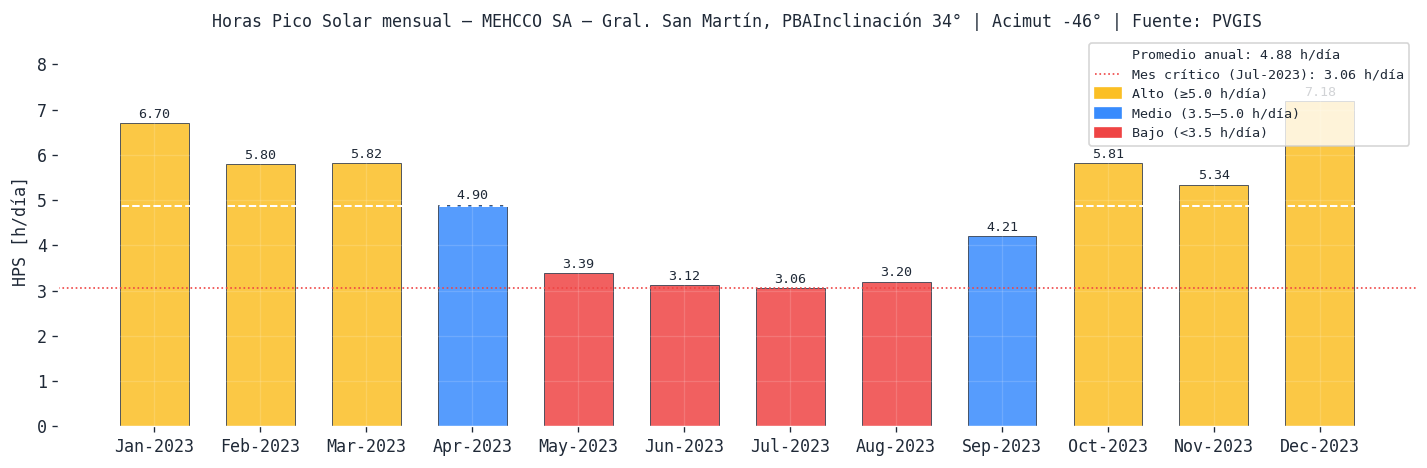

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

colores_hps = []
for h in hps_df['HPS (h/día)']:
    if h >= 5.0:
        colores_hps.append('#fbbf24')
    elif h >= 3.5:
        colores_hps.append('#388bfd')
    else:
        colores_hps.append('#ef4444')

bars = ax.bar(hps_df['Mes'], hps_df['HPS (h/día)'],
              color=colores_hps, alpha=0.85, width=0.65,
              edgecolor='#374151', linewidth=0.6)

for bar, val in zip(bars, hps_df['HPS (h/día)']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.axhline(hps_promedio, color='white', linestyle='--', linewidth=1.2,
           label=f'Promedio anual: {hps_promedio:.2f} h/día')
ax.axhline(hps_minimo, color='#ef4444', linestyle=':', linewidth=1,
           label=f'Mes crítico ({mes_critico}): {hps_minimo:.2f} h/día')

from matplotlib.patches import Patch
leyenda_extra = [
    Patch(color='#fbbf24', label='Alto (≥5.0 h/día)'),
    Patch(color='#388bfd', label='Medio (3.5–5.0 h/día)'),
    Patch(color='#ef4444', label='Bajo (<3.5 h/día)'),
]
ax.legend(handles=ax.get_legend_handles_labels()[0] + leyenda_extra,
          fontsize=8, loc='upper right')

ax.set_ylabel('HPS [h/día]')
ax.set_ylim(0, hps_df['HPS (h/día)'].max() * 1.2)
ax.set_title(
    f'Horas Pico Solar mensual — {NOMBRE_SITIO}'
    f'Inclinación {INCLINACION_GRADOS}° | Acimut {ACIMUT_GRADOS}° | Fuente: PVGIS',
    fontsize=10
)
plt.tight_layout()
plt.savefig('recurso_solar.png', bbox_inches='tight', dpi=120)
plt.show()


### 3.4 Verificación de condiciones extremas

In [ ]:

# Corrección de parámetros del panel por temperatura
def Voc_T(T):
    return PANEL['Voc_stc'] * (1 + PANEL['beta_oc'] / 100 * (T - 25))

def Vmpp_T(T):
    return PANEL['Vmpp_stc'] * (1 + PANEL['beta_oc'] / 100 * (T - 25))

def Isc_T(T):
    return PANEL['Isc_stc'] * (1 + PANEL['alpha_isc'] / 100 * (T - 25))

def Pmpp_T(T):
    return PANEL['Wp'] * (1 + PANEL['gamma_pmpp'] / 100 * (T - 25))

print(f"  Parámetros del panel a distintas temperaturas:")
print(f"  {'Parámetro':<12} {'STC (25°C)':>12} {'Frío ({:.0f}°C)'.format(T_CEL_MIN):>14} {'Calor ({:.0f}°C)'.format(T_CEL_MAX):>14}")
print(f"  {'─'*52}")
print(f"  {'Voc [V]':<12} {PANEL['Voc_stc']:>12.2f} {Voc_T(T_CEL_MIN):>14.2f} {Voc_T(T_CEL_MAX):>14.2f}")
print(f"  {'Vmpp [V]':<12} {PANEL['Vmpp_stc']:>12.2f} {Vmpp_T(T_CEL_MIN):>14.2f} {Vmpp_T(T_CEL_MAX):>14.2f}")
print(f"  {'Isc [A]':<12} {PANEL['Isc_stc']:>12.2f} {Isc_T(T_CEL_MIN):>14.2f} {Isc_T(T_CEL_MAX):>14.2f}")
print(f"  {'Pmpp [W]':<12} {PANEL['Wp']:>12.1f} {Pmpp_T(T_CEL_MIN):>14.1f} {Pmpp_T(T_CEL_MAX):>14.1f}")


  Parámetros del panel a distintas temperaturas:
  Parámetro      STC (25°C)    Frío (-5°C)   Calor (71°C)
  ────────────────────────────────────────────────────
  Voc [V]             49.90          53.49          44.39
  Vmpp [V]            41.70          44.70          37.10
  Isc [A]             15.92          15.73          16.21
  Pmpp [W]            625.0          679.4          541.6


---
## 4. Propuesta de potencia a instalar

### 4.1 Potencia FV propuesta y criterios


In [ ]:
import math

# Consumo diario en horario FV (estimación: 85% del consumo diario total
# ocurre en horario laboral para una industria de turno único)
FRACCION_CONSUMO_DIURNO = 0.85
consumo_diario_total   = hist['energia_kwh'].mean() / 30
consumo_diario_diurno  = consumo_diario_total * FRACCION_CONSUMO_DIURNO

# Potencia FV necesaria para cubrir distintas fracciones solares objetivos
print("Potencia FV necesaria según fracción solar objetivo")
print(f"(consumo diario diurno estimado: {consumo_diario_diurno:.1f} kWh/día)")
print()
print(f"  {'FS objetivo':>12} {'P_FV necesaria (kWp)':>22} {'Viabilidad'}")
print(f"  {'─'*55}")

for fs in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    E_obj = consumo_diario_diurno * fs
    P_fv  = E_obj / (hps_promedio * PR)
    # Área necesaria
    area_panel_m2 = (PANEL['largo_mm'] / 1000) * (PANEL['ancho_mm'] / 1000)
    n_paneles_est = math.ceil(P_fv * 1000 / PANEL['Wp'])
    area_necesaria = n_paneles_est * area_panel_m2 * 1.3  # factor de espaciado
    viabilidad = "✓" if P_fv <= P_CONTRATADA_KW and area_necesaria <= AREA_TECHO_M2 else "⚠ límite"
    print(f"  {fs*100:>10.0f}%  {P_fv:>18.1f} kWp  {viabilidad} "
          f"(~{n_paneles_est} paneles, ~{area_necesaria:.0f} m²)")

print()
print(f"  Restricciones:")
print(f"    Potencia contratada (techo regulatorio fácil) : {P_CONTRATADA_KW:.1f} kW")
print(f"    Área disponible en techo                      : {AREA_TECHO_M2} m²")
print(f"    Potencia AC del inversor seleccionado         : {INVERSOR['P_ac_nom_w']/1000:.1f} kW")


Potencia FV necesaria según fracción solar objetivo
(consumo diario diurno estimado: 134.4 kWh/día)

   FS objetivo   P_FV necesaria (kWp) Viabilidad
  ───────────────────────────────────────────────────────
          30%                10.6 kWp  ✓ (~17 paneles, ~65 m²)
          40%                14.1 kWp  ✓ (~23 paneles, ~88 m²)
          50%                17.7 kWp  ⚠ límite (~29 paneles, ~111 m²)
          60%                21.2 kWp  ⚠ límite (~34 paneles, ~130 m²)
          70%                24.7 kWp  ⚠ límite (~40 paneles, ~153 m²)
          80%                28.3 kWp  ⚠ límite (~46 paneles, ~176 m²)

  Restricciones:
    Potencia contratada (techo regulatorio fácil) : 16.0 kW
    Área disponible en techo                      : 140 m²
    Potencia AC del inversor seleccionado         : 15.0 kW


### 4.2 Potencia seleccionada y justificación

In [ ]:
# ── Potencia propuesta ───────────────────────────────────────
# Se propone usar la potencia del inversor seleccionado como referencia AC.
# El array DC se dimensiona con oversizing óptimo (110–130%).

P_inv_ac_kw  = INVERSOR['P_ac_nom_w'] / 1000
P_dc_max_inv = INVERSOR['P_dc_max_w'] / 1000

print(f"Inversor seleccionado : {INVERSOR['modelo']}")
print(f"  Potencia AC nominal : {P_inv_ac_kw:.1f} kW")
print(f"  Potencia DC máxima  : {P_dc_max_inv:.1f} kW")
print()

# Estimación de generación con esta potencia
E_fv_diaria_est  = P_inv_ac_kw * hps_promedio * PR
E_fv_anual_est   = P_inv_ac_kw * (hps_df['H(i) kWh/m²'].sum()) * PR
E_consumo_anual  = hist['energia_kwh'].mean() * 12
fraccion_solar   = E_fv_anual_est / E_consumo_anual * 100

print(f"Estimación de generación:")
print(f"  E diaria estimada   : {E_fv_diaria_est:.1f} kWh/día")
print(f"  E anual estimada    : {E_fv_anual_est:,.0f} kWh/año")
print(f"  Consumo anual est.  : {E_consumo_anual:,.0f} kWh/año")
print(f"  Fracción solar est. : {fraccion_solar:.1f}%")
print()
print(f"  Nota: la fracción solar real depende del array definitivo")
print(f"  que se calcula en la sección siguiente.")


Inversor seleccionado : Fronius Symo 15.0-3-M
  Potencia AC nominal : 15.0 kW
  Potencia DC máxima  : 22.5 kW

Estimación de generación:
  E diaria estimada   : 57.1 kWh/día
  E anual estimada    : 20,818 kWh/año
  Consumo anual est.  : 56,922 kWh/año
  Fracción solar est. : 36.6%

  Nota: la fracción solar real depende del array definitivo
  que se calcula en la sección siguiente.


---
## 5. Selección del inversor y del panel — Análisis de datasheets

### 5.1 Inversor seleccionado


In [ ]:
print(f"INVERSOR SELECCIONADO: {INVERSOR['modelo']}")
print("═" * 55)
print(f"  Potencia AC nominal        : {INVERSOR['P_ac_nom_w']:,} W  ({INVERSOR['P_ac_nom_w']/1000:.1f} kW)")
print(f"  Potencia DC máxima admis.  : {INVERSOR['P_dc_max_w']:,} W  ({INVERSOR['P_dc_max_w']/1000:.1f} kW)")
print(f"  Tensión DC máxima absoluta : {INVERSOR['V_dc_max']} V  ← techo de seguridad")
print(f"  Rango MPPT                 : {INVERSOR['V_mppt_min']} V — {INVERSOR['V_mppt_max']} V")
print(f"  Corriente DC máx. por MPPT : {INVERSOR['I_dc_max']} A")
print(f"  Corriente cortocircuito DC : {INVERSOR['I_sc_max']} A")
print(f"  Número de entradas MPPT    : {INVERSOR['n_mppt']}")
print(f"  Eficiencia máxima          : {INVERSOR['eta_max']*100:.1f}%")
print(f"  Eficiencia europea         : {INVERSOR['eta_euro']*100:.1f}%")
print(f"  Fases / Tensión AC         : {INVERSOR['fases']}F / {INVERSOR['V_ac']} V")
print("═" * 55)
print()
tensión_centro_mppt = (INVERSOR['V_mppt_min'] + INVERSOR['V_mppt_max']) / 2
print(f"  Centro del rango MPPT      : {tensión_centro_mppt:.0f} V  ← tensión objetivo del array")


INVERSOR SELECCIONADO: Fronius Symo 15.0-3-M
═══════════════════════════════════════════════════════
  Potencia AC nominal        : 15,000 W  (15.0 kW)
  Potencia DC máxima admis.  : 22,500 W  (22.5 kW)
  Tensión DC máxima absoluta : 1000 V  ← techo de seguridad
  Rango MPPT                 : 200 V — 800 V
  Corriente DC máx. por MPPT : 27.0 A
  Corriente cortocircuito DC : 33.0 A
  Número de entradas MPPT    : 2
  Eficiencia máxima          : 97.5%
  Eficiencia europea         : 97.1%
  Fases / Tensión AC         : 3F / 380 V
═══════════════════════════════════════════════════════

  Centro del rango MPPT      : 500 V  ← tensión objetivo del array


### 5.2 Panel seleccionado

In [ ]:
print(f"PANEL SELECCIONADO: {PANEL['modelo']}")
print("═" * 55)
print(f"  Potencia pico STC          : {PANEL['Wp']} Wp")
print(f"  Voc STC                    : {PANEL['Voc_stc']:.2f} V")
print(f"  Vmpp STC                   : {PANEL['Vmpp_stc']:.2f} V")
print(f"  Isc STC                    : {PANEL['Isc_stc']:.2f} A")
print(f"  Impp STC                   : {PANEL['Impp_stc']:.2f} A")
print(f"  Coef. temp. Voc (β)        : {PANEL['beta_oc']:.3f} %/°C")
print(f"  Coef. temp. Isc (α)        : {PANEL['alpha_isc']:.3f} %/°C")
print(f"  Coef. temp. Pmpp (γ)       : {PANEL['gamma_pmpp']:.3f} %/°C")
print(f"  NOCT                       : {PANEL['NOCT']}°C")
print(f"  Dimensiones                : {PANEL['largo_mm']} × {PANEL['ancho_mm']} mm")
print(f"  Tensión máxima del sistema : {PANEL['V_sys_max']} V")
print("═" * 55)
area_panel = (PANEL['largo_mm']/1000) * (PANEL['ancho_mm']/1000)
print(f"  Área por panel             : {area_panel:.3f} m²")
print(f"  Eficiencia STC             : {PANEL['Wp'] / (area_panel * 1000) * 100:.1f}%")


PANEL SELECCIONADO: Vertex TSM-NEG19RC.20 625W
═══════════════════════════════════════════════════════
  Potencia pico STC          : 625 Wp
  Voc STC                    : 49.90 V
  Vmpp STC                   : 41.70 V
  Isc STC                    : 15.92 A
  Impp STC                   : 15.00 A
  Coef. temp. Voc (β)        : -0.240 %/°C
  Coef. temp. Isc (α)        : 0.040 %/°C
  Coef. temp. Pmpp (γ)       : -0.290 %/°C
  NOCT                       : 43°C
  Dimensiones                : 2382 × 1234 mm
  Tensión máxima del sistema : 1500 V
═══════════════════════════════════════════════════════
  Área por panel             : 2.939 m²
  Eficiencia STC             : 21.3%


---
## 6. Cálculo del array — Strings en serie y en paralelo

### 6.1 Número de paneles en serie

El cálculo se realiza en tres condiciones de temperatura para garantizar operación segura
en todos los escenarios posibles:

$$N_{serie,max,abs} = \left\lfloor \frac{V_{dc,max}}{V_{oc}(T_{min})} \right\rfloor$$

$$N_{serie,max,MPPT} = \left\lfloor \frac{V_{MPPT,max}}{V_{mpp}(T_{min})} \right\rfloor$$

$$N_{serie,min} = \left\lceil \frac{V_{MPPT,min}}{V_{mpp}(T_{max})} \right\rceil$$


In [ ]:
import math

# Valores del panel a las temperaturas extremas
Voc_frio   = Voc_T(T_CEL_MIN)
Vmpp_frio  = Vmpp_T(T_CEL_MIN)
Vmpp_calor = Vmpp_T(T_CEL_MAX)

# ── Condición 1 — Temperatura mínima: límite de seguridad absoluto ──
# En frío la Voc sube → riesgo de superar V_dc_max del inversor
N_max_abs  = math.floor(INVERSOR['V_dc_max'] / Voc_frio)

# ── Condición 2 — Temperatura mínima: límite MPPT superior ──────────
# La Vmpp en frío también sube → no debe superar V_mppt_max
N_max_mppt = math.floor(INVERSOR['V_mppt_max'] / Vmpp_frio)

# ── Condición 3 — Temperatura máxima: límite MPPT inferior ──────────
# En calor la Vmpp baja → debe mantenerse sobre V_mppt_min
N_min_mppt = math.ceil(INVERSOR['V_mppt_min'] / Vmpp_calor)

# Límite superior definitivo
N_max = min(N_max_abs, N_max_mppt)


print("CÁLCULO DE PANELES EN SERIE")
print("═" * 60)
print()
print(f"  Condición 1 — T_min = {T_CEL_MIN}°C (peor caso sobretensión)")
print(f"    Voc({T_CEL_MIN}°C)    = {Voc_frio:.3f} V/panel")
print(f"    N_max_abs  = floor({INVERSOR['V_dc_max']} / {Voc_frio:.3f}) = {N_max_abs} paneles")
print()
print(f"  Condición 2 — T_min = {T_CEL_MIN}°C (límite MPPT superior)")
print(f"    Vmpp({T_CEL_MIN}°C)   = {Vmpp_frio:.3f} V/panel")
print(f"    N_max_mppt = floor({INVERSOR['V_mppt_max']} / {Vmpp_frio:.3f}) = {N_max_mppt} paneles")
print()
print(f"  Condición 3 — T_max = {T_CEL_MAX}°C (peor caso subtensión)")
print(f"    Vmpp({T_CEL_MAX}°C)   = {Vmpp_calor:.3f} V/panel")
print(f"    N_min_mppt = ceil({INVERSOR['V_mppt_min']} / {Vmpp_calor:.3f}) = {N_min_mppt} paneles")
print()
print(f"  ─────────────────────────────────────────────────────")
print(f"  Límite superior definitivo : min({N_max_abs}, {N_max_mppt}) = {N_max} paneles")
print(f"  RANGO VÁLIDO               : {N_min_mppt} ≤ N_serie ≤ {N_max}")
print()
if N_min_mppt <= N_max:
    print(f"  ✓ Rango válido — se puede diseñar el string")
else:
    print(f"  ✗ ERROR: no hay rango válido — revisar combinación panel/inversor")


CÁLCULO DE PANELES EN SERIE
════════════════════════════════════════════════════════════

  Condición 1 — T_min = -5.0°C (peor caso sobretensión)
    Voc(-5.0°C)    = 53.493 V/panel
    N_max_abs  = floor(1000 / 53.493) = 18 paneles

  Condición 2 — T_min = -5.0°C (límite MPPT superior)
    Vmpp(-5.0°C)   = 44.702 V/panel
    N_max_mppt = floor(800 / 44.702) = 17 paneles

  Condición 3 — T_max = 71.0°C (peor caso subtensión)
    Vmpp(71.0°C)   = 37.096 V/panel
    N_min_mppt = ceil(200 / 37.096) = 6 paneles

  ─────────────────────────────────────────────────────
  Límite superior definitivo : min(18, 17) = 17 paneles
  RANGO VÁLIDO               : 6 ≤ N_serie ≤ 17

  ✓ Rango válido — se puede diseñar el string


### 6.2 Elección del número de paneles en serie y verificación

In [ ]:
# ── Elección de N_serie ──────────────────────────────────────────────
# Se elige el valor dentro del rango que hace trabajar al array
# en la zona central del rango MPPT a STC.
# Objetivo: Vmpp_string_STC ≈ centro del rango MPPT

N_SERIE =    N_max -3 # le equito dos para optimizar el rango de trabajo del inversor

# Verificación completa del string elegido
V_oc_string_frio   = N_SERIE * Voc_frio
V_mpp_string_STC   = N_SERIE * PANEL['Vmpp_stc']
V_mpp_string_frio  = N_SERIE * Vmpp_frio
V_mpp_string_calor = N_SERIE * Vmpp_calor

centro_mppt = (INVERSOR['V_mppt_min'] + INVERSOR['V_mppt_max']) / 2
rango_mppt  = INVERSOR['V_mppt_max'] - INVERSOR['V_mppt_min']

print(f"STRING ELEGIDO: {N_SERIE} paneles en serie")
print("═" * 60)
print()
print(f"  Tensiones del string:")
print(f"    Vmpp a STC  (25°C)  : {V_mpp_string_STC:.1f} V")
print(f"    Vmpp a frío ({T_CEL_MIN}°C) : {V_mpp_string_frio:.1f} V")
print(f"    Vmpp a calor ({T_CEL_MAX}°C): {V_mpp_string_calor:.1f} V")
print(f"    Voc  a frío ({T_CEL_MIN}°C) : {V_oc_string_frio:.1f} V")
print()
print(f"  Verificaciones de seguridad:")

# Check 1: Voc < V_dc_max
ok1 = V_oc_string_frio < INVERSOR['V_dc_max']
print(f"    Voc({T_CEL_MIN}°C) = {V_oc_string_frio:.1f} V < V_dc_max = {INVERSOR['V_dc_max']} V  "
      f"{'✓ OK' if ok1 else '✗ FALLA — reducir N_SERIE'}")

# Check 2: Vmpp_frio < V_mppt_max
ok2 = V_mpp_string_frio < INVERSOR['V_mppt_max']
print(f"    Vmpp({T_CEL_MIN}°C) = {V_mpp_string_frio:.1f} V < V_mppt_max = {INVERSOR['V_mppt_max']} V  "
      f"{'✓ OK' if ok2 else '✗ FALLA — reducir N_SERIE'}")

# Check 3: Vmpp_calor > V_mppt_min
ok3 = V_mpp_string_calor > INVERSOR['V_mppt_min']
print(f"    Vmpp({T_CEL_MAX}°C)  = {V_mpp_string_calor:.1f} V > V_mppt_min = {INVERSOR['V_mppt_min']} V  "
      f"{'✓ OK' if ok3 else '✗ FALLA — aumentar N_SERIE'}")

# Check 4: trabajando cerca del centro del MPPT, datos buscados en google :D
# busca la tensión en condiciones estpandar y le resta el valor mínimo de tensión
# MPPT del inversor para ver qué porcentaje se encuentra trabajando el string de paneles
posicion_pct = (V_mpp_string_STC - INVERSOR['V_mppt_min']) / rango_mppt * 100
print(f"    Vmpp_STC en el {posicion_pct:.0f}% del rango MPPT  "
      f"{'✓ Buena zona de trabajo' if 65 <= posicion_pct <= 80 else '⚠ Considerar ajustar N_SERIE'}")

print()
if ok1 and ok2 and ok3:
    print(f"  ✓ CONFIGURACIÓN VÁLIDA — {N_SERIE} paneles en serie")
else:
    print(f"  ✗ CONFIGURACIÓN INVÁLIDA — ajustar N_SERIE dentro del rango {N_min_mppt}–{N_max}")


STRING ELEGIDO: 14 paneles en serie
════════════════════════════════════════════════════════════

  Tensiones del string:
    Vmpp a STC  (25°C)  : 583.8 V
    Vmpp a frío (-5.0°C) : 625.8 V
    Vmpp a calor (71.0°C): 519.3 V
    Voc  a frío (-5.0°C) : 748.9 V

  Verificaciones de seguridad:
    Voc(-5.0°C) = 748.9 V < V_dc_max = 1000 V  ✓ OK
    Vmpp(-5.0°C) = 625.8 V < V_mppt_max = 800 V  ✓ OK
    Vmpp(71.0°C)  = 519.3 V > V_mppt_min = 200 V  ✓ OK
    Vmpp_STC en el 64% del rango MPPT  ⚠ Considerar ajustar N_SERIE

  ✓ CONFIGURACIÓN VÁLIDA — 14 paneles en serie


### 6.3 Número de strings en paralelo

In [ ]:
# ── Límite por corriente de entrada del inversor ─────────────────────
N_par_max_corriente = math.floor(INVERSOR['I_dc_max'] / PANEL['Isc_stc'])
N_par_max_isc       = math.floor(INVERSOR['I_sc_max'] / PANEL['Isc_stc'])

print(f"CÁLCULO DE STRINGS EN PARALELO")
print("═" * 60)
print()
print(f"  Límite por corriente MPPT  : floor({INVERSOR['I_dc_max']} / {PANEL['Isc_stc']}) = {N_par_max_corriente} strings")
print(f"  Límite por corriente Isc   : floor({INVERSOR['I_sc_max']} / {PANEL['Isc_stc']}) = {N_par_max_isc} strings")
print(f"  Límite por MPPT disponibles: {INVERSOR['n_mppt']} entradas")
print()

N_PARALELO = 2   # ← AJUSTAR según potencia objetivo


# Acá incluimos la incidencia de la "bifacialidad", no estamos muy seguro de esto
P_dc_total_w  = N_SERIE * N_PARALELO * PANEL['Wp'] * (1+ PANEL['ganancia_bifacial'])
P_dc_total_kw = P_dc_total_w / 1000
oversizing    = P_dc_total_w / INVERSOR['P_ac_nom_w'] * 100

print(f"  Strings en paralelo elegidos : {N_PARALELO}")
print(f"  Total paneles                : {N_SERIE} × {N_PARALELO} = {N_SERIE * N_PARALELO} paneles")
print(f"  Potencia DC total            : {P_dc_total_w:,} W  ({P_dc_total_kw:.2f} kWp)")
print(f"  Oversizing DC/AC             : {oversizing:.1f}%")

if oversizing < 100:
    estado_os = "⚠ Sub-dimensionado — el inversor nunca llega a nominal"
elif 100 <= oversizing <= 110:
    estado_os = "✓ Conservador — sin clipping"
elif 110 < oversizing <= 130:
    estado_os = "✓ Óptimo para Buenos Aires"
elif 130 < oversizing <= 150:
    estado_os = "⚠ Agresivo — verificar P_dc_max del inversor"
else:
    estado_os = "✗ Excesivo — puede invalidar garantía del inversor"
print(f"  Evaluación                   : {estado_os}")
print()

ok_pdc = P_dc_total_w <= INVERSOR['P_dc_max_w']
print(f"  P_dc_total ({P_dc_total_w:,} W) ≤ P_dc_max inversor ({INVERSOR['P_dc_max_w']:,} W)  "
      f"{'✓ OK' if ok_pdc else '✗ SUPERA LÍMITE — reducir N_PARALELO'}")


CÁLCULO DE STRINGS EN PARALELO
════════════════════════════════════════════════════════════

  Límite por corriente MPPT  : floor(27.0 / 15.92) = 1 strings
  Límite por corriente Isc   : floor(33.0 / 15.92) = 2 strings
  Límite por MPPT disponibles: 2 entradas

  Strings en paralelo elegidos : 2
  Total paneles                : 14 × 2 = 28 paneles
  Potencia DC total            : 19,250.0 W  (19.25 kWp)
  Oversizing DC/AC             : 128.3%
  Evaluación                   : ✓ Óptimo para Buenos Aires

  P_dc_total (19,250.0 W) ≤ P_dc_max inversor (22,500 W)  ✓ OK


---
## 7. Verificación en condiciones extremas

### 7.1 Peor caso de sobrecorriente (IEC 62548)

$$I_{campo,max} = N_{paralelo} \times I_{sc,STC} \times 1{,}25$$


In [ ]:
# Factor de seguridad, buscamos en google el dato
FACTOR_ISC = 1.25

I_sc_campo    = N_PARALELO * PANEL['Isc_stc']
I_campo_max   = I_sc_campo * FACTOR_ISC
I_impp_campo  = N_PARALELO * PANEL['Impp_stc']

print("VERIFICACIÓN DE CORRIENTES — PEOR CASO")
print("═" * 60)
print()
print(f"  Corriente Impp del campo     : {I_impp_campo:.2f} A  (operación normal)")
print(f"  Corriente Isc del campo      : {I_sc_campo:.2f} A  (cortocircuito STC)")
print(f"  Corriente de diseño (×1,25)  : {I_campo_max:.2f} A  ← base para conductores")
print()
ok_isc = I_sc_campo <= INVERSOR['I_sc_max']
print(f"  I_sc_campo ({I_sc_campo:.2f}A) ≤ I_sc_max inversor ({INVERSOR['I_sc_max']}A)  "
      f"{'✓ OK' if ok_isc else '✗ FALLA'}")


VERIFICACIÓN DE CORRIENTES — PEOR CASO
════════════════════════════════════════════════════════════

  Corriente Impp del campo     : 30.00 A  (operación normal)
  Corriente Isc del campo      : 31.84 A  (cortocircuito STC)
  Corriente de diseño (×1,25)  : 39.80 A  ← base para conductores

  I_sc_campo (31.84A) ≤ I_sc_max inversor (33.0A)  ✓ OK


### 7.2 Resumen del diseño del array

In [ ]:
# Cálculos de área
area_panel_m2   = (PANEL['largo_mm']/1000) * (PANEL['ancho_mm']/1000)
n_total_paneles = N_SERIE * N_PARALELO
area_paneles    = n_total_paneles * area_panel_m2
area_con_sep    = area_paneles * 1.30
estado_techo    = '🟢 **Suficiente**' if area_con_sep <= AREA_TECHO_M2 else '🔴 **Insuficiente** (revisar array o techo)'

# Generamos el texto en formato Markdown
resumen_md = f"""
### ☀️ Resumen del Diseño del Array

| Parámetro | Detalle |
| :--- | :--- |
| **Panel** | {PANEL['modelo']} |
| **Inversor** | {INVERSOR['modelo']} |
| **Configuración** | {N_SERIE}S × {N_PARALELO}P = {n_total_paneles} paneles totales |
| **Potencia DC** | {P_dc_total_kw:.2f} kWp |
| **Potencia AC** | {INVERSOR['P_ac_nom_w']/1000:.1f} kW AC |
| **Oversizing DC/AC** | {oversizing:.1f}% |

#### ⚡ Verificaciones Eléctricas
| Parámetro | Condición | Estado |
| :--- | :--- | :--- |
| **Voc a {T_CEL_MIN}°C** | {V_oc_string_frio:.1f} V < {INVERSOR['V_dc_max']} V | ✓ OK |
| **Vmpp frío** | {V_mpp_string_frio:.1f} V < {INVERSOR['V_mppt_max']} V | ✓ OK |
| **Vmpp calor** | {V_mpp_string_calor:.1f} V > {INVERSOR['V_mppt_min']} V | ✓ OK |
| **Corriente Máx** | {I_campo_max:.2f} A  | ✓ OK |

#### 📐 Verificación de Espacio
| Medida | Valor |
| :--- | :--- |
| Área neta de paneles | {area_paneles:.1f} m² |
| Área total (con sep.) | {area_con_sep:.1f} m² |
| Área disponible | {AREA_TECHO_M2} m² |
| **Estado del techo** | {estado_techo} |
"""

# Mostramos el resultado renderizado en el Notebook
display(Markdown(resumen_md))


### ☀️ Resumen del Diseño del Array

| Parámetro | Detalle |
| :--- | :--- |
| **Panel** | Vertex TSM-NEG19RC.20 625W |
| **Inversor** | Fronius Symo 15.0-3-M |
| **Configuración** | 14S × 2P = 28 paneles totales |
| **Potencia DC** | 19.25 kWp |
| **Potencia AC** | 15.0 kW AC |
| **Oversizing DC/AC** | 128.3% |

#### ⚡ Verificaciones Eléctricas
| Parámetro | Condición | Estado |
| :--- | :--- | :--- |
| **Voc a -5.0°C** | 748.9 V < 1000 V | ✓ OK |
| **Vmpp frío** | 625.8 V < 800 V | ✓ OK |
| **Vmpp calor** | 519.3 V > 200 V | ✓ OK |
| **Corriente Máx** | 39.80 A  | ✓ OK |

#### 📐 Verificación de Espacio
| Medida | Valor |
| :--- | :--- |
| Área neta de paneles | 82.3 m² |
| Área total (con sep.) | 107.0 m² |
| Área disponible | 140 m² |
| **Estado del techo** | 🟢 **Suficiente** |


---
## 8. Estimación de generación anual

### 8.1 Performance Ratio — desglose de pérdidas

$$PR = 1 - \sum L_i$$


In [ ]:
# Desglose del PR buscado en google
perdidas = {
    'Temperatura de paneles'  : 0.070,
    'Suciedad y polvo'        : 0.030,
    'Sombreado (estimado)'    : 0.020,
    'Mismatch entre paneles'  : 0.010,
    'Pérdidas en cableado DC' : 0.015,
    'Pérdidas en cableado AC' : 0.008,
    'Eficiencia del inversor' : 1 - INVERSOR['eta_euro'],
    'Disponibilidad sistema'  : 0.010,
}
PR_calculado = 1 - sum(perdidas.values())

print("DESGLOSE DEL PERFORMANCE RATIO")
print("═" * 45)
for concepto, perdida in perdidas.items():
    print(f"  {concepto:<30} : -{perdida*100:.1f}%")
print("─" * 45)
print(f"  PR calculado              : {PR_calculado:.3f}  ({PR_calculado*100:.1f}%)")
print(f"  PR usado en cálculo       : {PR:.3f}  ({PR*100:.1f}%)")
print()
if abs(PR - PR_calculado) > 0.03:
    print(f"  ⚠ Diferencia > 3% — revisar el PR en los parámetros editables")
else:
    print(f"  ✓ PR consistente con el desglose de pérdidas")


DESGLOSE DEL PERFORMANCE RATIO
═════════════════════════════════════════════
  Temperatura de paneles         : -7.0%
  Suciedad y polvo               : -3.0%
  Sombreado (estimado)           : -2.0%
  Mismatch entre paneles         : -1.0%
  Pérdidas en cableado DC        : -1.5%
  Pérdidas en cableado AC        : -0.8%
  Eficiencia del inversor        : -2.9%
  Disponibilidad sistema         : -1.0%
─────────────────────────────────────────────
  PR calculado              : 0.808  (80.8%)
  PR usado en cálculo       : 0.780  (78.0%)

  ✓ PR consistente con el desglose de pérdidas


### 8.2 Generación mensual y anual

In [ ]:
# Generación mensual con el método de suma HPS
gen_df = hps_df.copy()
gen_df['Generación (kWh)'] = (
    P_dc_total_kw * gen_df['H(i) kWh/m²'] * PR
).round(0).astype(int)

# Consumo estimado mensual (usar histórico + proyección para meses sin datos)
consumo_base = hist['energia_kwh'].mean()
gen_df['Consumo est. (kWh)'] = consumo_base.round(0).astype(int)

gen_df['Cobertura (%)'] = (
    gen_df['Generación (kWh)'] / gen_df['Consumo est. (kWh)'] * 100
).round(1)

E_anual_fv   = gen_df['Generación (kWh)'].sum()
E_anual_cons = gen_df['Consumo est. (kWh)'].sum()
fs_anual     = E_anual_fv / E_anual_cons * 100
e_spec       = E_anual_fv / P_dc_total_kw

print("GENERACIÓN ESTIMADA MENSUAL")
print(f"Sistema: {N_SERIE}S×{N_PARALELO}P — {P_dc_total_kw:.2f} kWp DC — PR={PR}")
print()
print(f"  {'Mes':<8} {'H(i) kWh/m²':>12} {'HPS h/día':>10} {'Gen. kWh':>10} {'Consumo kWh':>13} {'Cobertura':>10}")
print(f"  {'─'*65}")
for _, row in gen_df.iterrows():
    print(f"  {row['Mes']:<8} {row['H(i) kWh/m²']:>12.1f} {row['HPS (h/día)']:>10.2f} "
          f"{row['Generación (kWh)']:>10,} {row['Consumo est. (kWh)']:>13,} {row['Cobertura (%)']:>9.1f}%")
print(f"  {'─'*65}")
print(f"  {'TOTAL/AÑO':<8} {gen_df['H(i) kWh/m²'].sum():>12.0f} {'':>10} "
      f"{E_anual_fv:>10,} {E_anual_cons:>13,} {fs_anual:>9.1f}%")
print()
print(f"  Generación anual          : {E_anual_fv:,} kWh/año")
print(f"  Producción específica     : {e_spec:.0f} kWh/kWp/año  (esperado: 1300–1600)")
print(f"  Fracción solar anual      : {fs_anual:.1f}%")


GENERACIÓN ESTIMADA MENSUAL
Sistema: 14S×2P — 19.25 kWp DC — PR=0.78

  Mes       H(i) kWh/m²  HPS h/día   Gen. kWh   Consumo kWh  Cobertura
  ─────────────────────────────────────────────────────────────────
  Jan-2023        207.6       6.70      3,117         4,744      65.7%
  Feb-2023        162.4       5.80      2,438         4,744      51.4%
  Mar-2023        180.4       5.82      2,709         4,744      57.1%
  Apr-2023        147.0       4.90      2,207         4,744      46.5%
  May-2023        105.2       3.39      1,580         4,744      33.3%
  Jun-2023         93.6       3.12      1,405         4,744      29.6%
  Jul-2023         94.8       3.06      1,423         4,744      30.0%
  Aug-2023         99.2       3.20      1,489         4,744      31.4%
  Sep-2023        126.2       4.21      1,895         4,744      39.9%
  Oct-2023        180.1       5.81      2,704         4,744      57.0%
  Nov-2023        160.2       5.34      2,405         4,744      50.7%
  Dec-2023

### 8.3 Gráfico — Generación vs consumo mensual

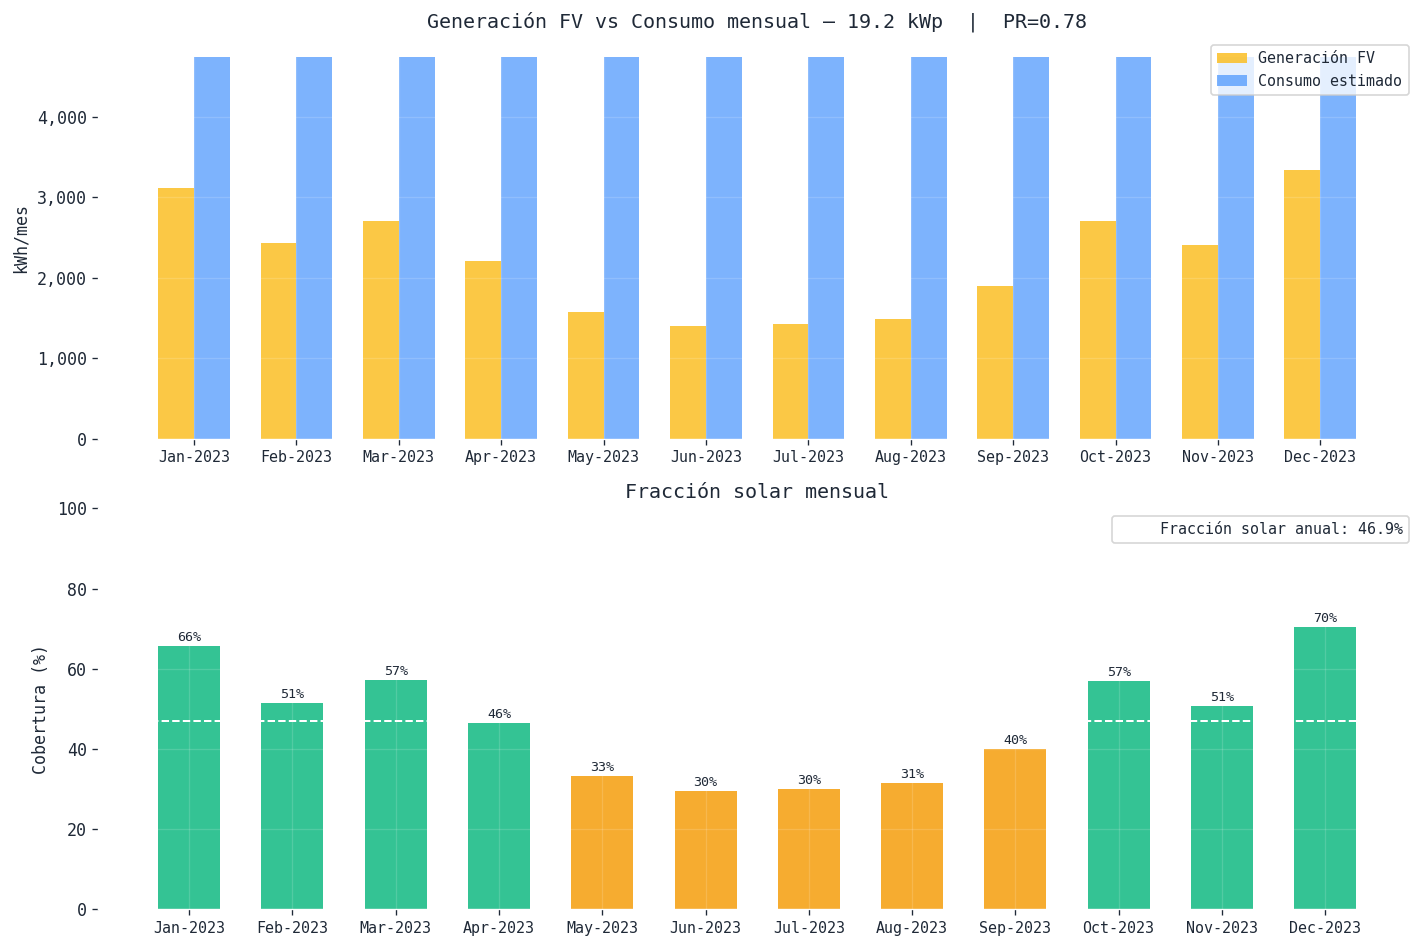

Generación anual total: 26,714 kWh/año
Fracción solar anual  : 46.9%


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

meses = gen_df['Mes']
x = np.arange(len(meses))
w = 0.35

# ── Barras generación vs consumo ────────────────────────────
b1 = ax1.bar(x - w/2, gen_df['Generación (kWh)'], w,
             color='#fbbf24', alpha=0.85, label='Generación FV')
b2 = ax1.bar(x + w/2, gen_df['Consumo est. (kWh)'], w,
             color='#388bfd', alpha=0.65, label='Consumo estimado')
ax1.set_xticks(x)
ax1.set_xticklabels(meses, fontsize=9)
ax1.set_ylabel('kWh/mes')
ax1.set_title(f'Generación FV vs Consumo mensual — {P_dc_total_kw:.1f} kWp  |  PR={PR}')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

# ── Cobertura mensual ────────────────────────────────────────
bar_colors = ['#10b981' if c >= 40 else '#f59e0b' if c >= 25 else '#ef4444'
              for c in gen_df['Cobertura (%)']]
ax2.bar(x, gen_df['Cobertura (%)'], color=bar_colors, alpha=0.85, width=0.6)
ax2.axhline(fs_anual, color='white', linestyle='--', linewidth=1.2,
            label=f'Fracción solar anual: {fs_anual:.1f}%')
for i, (xi, val) in enumerate(zip(x, gen_df['Cobertura (%)'])):
    ax2.text(xi, val + 0.5, f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(meses, fontsize=9)
ax2.set_ylabel('Cobertura (%)')
ax2.set_title('Fracción solar mensual')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('generacion_anual.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"Generación anual total: {E_anual_fv:,} kWh/año")
print(f"Fracción solar anual  : {fs_anual:.1f}%")


---
## 9. Resumen ejecutivo del diseño


In [ ]:
resumen_ejecutivo_md = f"""
### 📊 Resumen Ejecutivo — Sistema FV On-Grid
**MEHCCO SA — T2 EDENOR**

| 📍 Sitio | Detalle |
| :--- | :--- |
| **Ubicación** | {NOMBRE_SITIO} |
| **Coordenadas** | {LATITUD}°, {LONGITUD}° |
| **Inclinación / Acimut** | {INCLINACION_GRADOS}° | {ACIMUT_GRADOS}° |

<br>

| ⚙️ Equipos y Array | Especificaciones |
| :--- | :--- |
| **Panel** | {PANEL['modelo']} |
| **Inversor** | {INVERSOR['modelo']} |
| **Configuración** | {N_SERIE} paneles serie × {N_PARALELO} strings paralelo = {N_SERIE*N_PARALELO} paneles |
| **Potencia DC** | {P_dc_total_kw:.2f} kWp |
| **Potencia AC** | {INVERSOR['P_ac_nom_w']/1000:.1f} kW (inversor) |
| **Oversizing** | {oversizing:.1f}% |

<br>

| ⚡ Generación Estimada | Valores |
| :--- | :--- |
| **Energía anual estimada** | {E_anual_fv:,} kWh/año |
| **Prod. específica** | {e_spec:.0f} kWh/kWp/año |
| **Fracción solar** | {fs_anual:.1f}% |
| **Performance Ratio** | {PR:.2f} ({PR*100:.0f}%) |

<br>

| 🧾 Estado Actual de la Factura | Valores |
| :--- | :--- |
| **Consumo mensual promedio** | {hist['energia_kwh'].mean():,.0f} kWh/mes |
| **Potencia contratada** | {P_CONTRATADA_KW:.1f} kW |
| **Demanda máxima real** | {FACTURA['potencia_max_kw']:.2f} kW ⚠ *excede contrato* |
| **Total factura referencia** | $ {FACTURA['total_factura']:,} |
| **Precio efectivo kWh** | $ {p_efectivo:,.0f}/kWh |
"""

display(Markdown(resumen_ejecutivo_md))


### 📊 Resumen Ejecutivo — Sistema FV On-Grid
**MEHCCO SA — T2 EDENOR**

| 📍 Sitio | Detalle |
| :--- | :--- |
| **Ubicación** | MEHCCO SA — Gral. San Martín, PBA |
| **Coordenadas** | -34.5747566°, -58.5564361° |
| **Inclinación / Acimut** | 34° | -46° |

<br>

| ⚙️ Equipos y Array | Especificaciones |
| :--- | :--- |
| **Panel** | Vertex TSM-NEG19RC.20 625W |
| **Inversor** | Fronius Symo 15.0-3-M |
| **Configuración** | 14 paneles serie × 2 strings paralelo = 28 paneles |
| **Potencia DC** | 19.25 kWp |
| **Potencia AC** | 15.0 kW (inversor) |
| **Oversizing** | 128.3% |

<br>

| ⚡ Generación Estimada | Valores |
| :--- | :--- |
| **Energía anual estimada** | 26,714 kWh/año |
| **Prod. específica** | 1388 kWh/kWp/año |
| **Fracción solar** | 46.9% |
| **Performance Ratio** | 0.78 (78%) |

<br>

| 🧾 Estado Actual de la Factura | Valores |
| :--- | :--- |
| **Consumo mensual promedio** | 4,744 kWh/mes |
| **Potencia contratada** | 16.0 kW |
| **Demanda máxima real** | 34.68 kW ⚠ *excede contrato* |
| **Total factura referencia** | $ 2,101,720 |
| **Precio efectivo kWh** | $ 494/kWh |
